<a href="https://colab.research.google.com/github/FazrynPVNK/NLP_ImawanFajrin-2302010071-/blob/main/UTS_NLP_IMAWANFAJRIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (2).csv


## Load Dataset
Dataset yang digunakan adalah IMDb Movie Review Dataset yang berisi 50.000 ulasan film dengan label sentimen positif dan negatif.


In [91]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Eksplorasi Data
Tahap ini dilakukan untuk melihat jumlah data serta distribusi label sentimen dalam dataset.

In [92]:
df['clean_review'] = df['review'].apply(preprocess)

## Hasil Preprocessing
Tahap ini digunakan untuk memastikan bahwa kolom `clean_review` telah berhasil dibuat.

In [93]:
print(df.columns)

Index(['review', 'sentiment', 'clean_review'], dtype='object')


## Hasil Preprocessing
Tahap ini digunakan untuk memastikan bahwa kolom `clean_review` telah berhasil dibuat.

In [94]:
tokenized_reviews = [text.split() for text in df['clean_review']]


## Tokenization
Teks dipecah menjadi list kata untuk kebutuhan representasi berbasis kata.

In [95]:
print(df.shape)
df['sentiment'].value_counts()

(50000, 3)


,count
sentiment,
positive,25000
negative,25000


## Eksplorasi Data
Tahap ini dilakukan untuk melihat jumlah data dan distribusi label sentimen dalam dataset.


In [96]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

## Transformasi Label
Label sentimen diubah menjadi numerik:
- positive → 1
- negative → 0

In [97]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# INI YANG PENTING
df['clean_review'] = df['review'].apply(preprocess)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Text Preprocessing
Tahapan preprocessing dilakukan untuk membersihkan teks sebelum diproses lebih lanjut.

Langkah-langkah:
- Lowercasing
- Cleaning (regex)
- Tokenization
- Stopword Removal
- Lemmatization

Hasil preprocessing disimpan dalam kolom `clean_review`.

In [98]:
print(df.columns)

Index(['review', 'sentiment', 'clean_review'], dtype='object')


## Hasil Preprocessing
Tahap ini digunakan untuk memastikan bahwa kolom `clean_review` telah berhasil dibuat.

In [99]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

## Text Preprocessing
Tahapan preprocessing dilakukan untuk membersihkan teks sebelum diproses lebih lanjut.

Langkah-langkah:
- Lowercasing
- Cleaning (regex)
- Tokenization
- Stopword Removal
- Lemmatization

Hasil preprocessing disimpan dalam kolom `clean_review`.

In [100]:
!pip install gensim

In [101]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

## Load Dataset
Dataset yang digunakan adalah IMDb Movie Review Dataset yang berisi 50.000 ulasan film dengan label sentimen positif dan negatif.


In [102]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

## Text Preprocessing
Tahapan preprocessing dilakukan untuk membersihkan teks sebelum diproses lebih lanjut.

Langkah-langkah:
- Lowercasing
- Cleaning (regex)
- Tokenization
- Stopword Removal
- Lemmatization

Hasil preprocessing disimpan dalam kolom `clean_review`.

In [103]:
df['clean_review'] = df['review'].apply(preprocess)

## Text Preprocessing
Tahapan preprocessing dilakukan untuk membersihkan teks sebelum diproses lebih lanjut.

Langkah-langkah:
- Lowercasing
- Cleaning (regex)
- Tokenization
- Stopword Removal
- Lemmatization

Hasil preprocessing disimpan dalam kolom `clean_review`.

In [104]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_review'])

## Feature Extraction: Bag of Words
Metode Bag of Words digunakan untuk mengubah teks menjadi representasi numerik berdasarkan frekuensi kata.

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_review'])

## Feature Extraction: TF-IDF
TF-IDF digunakan untuk memberikan bobot pada kata berdasarkan tingkat kepentingannya dalam dokumen.

In [106]:
y = df['sentiment']

## Menentukan Label
Variabel target yang digunakan adalah kolom sentiment.

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Model
model_bow = MultinomialNB()
model_tfidf = MultinomialNB()

# Training
model_bow.fit(X_train_bow, y_train)
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

## Split Data dan Training Model
Data dibagi menjadi training dan testing dengan rasio 80:20.
Model yang digunakan adalah Multinomial Naive Bayes.

In [108]:
y_pred_bow = model_bow.predict(X_test_bow)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

## Prediksi Model
Model digunakan untuk memprediksi sentimen pada data testing.

In [109]:
from sklearn.metrics import accuracy_score

acc_bow = accuracy_score(y_test, y_pred_bow)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("BoW:", acc_bow)
print("TF-IDF:", acc_tfidf)

BoW: 0.8456
TF-IDF: 0.852


## Evaluasi Model
Evaluasi dilakukan menggunakan accuracy.

Hasil:
- Bag of Words: 84.56%
- TF-IDF: 85.20%

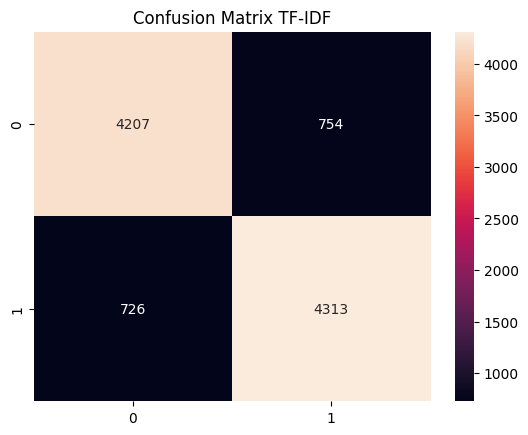

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tfidf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix TF-IDF")
plt.show()

## Confusion Matrix
Confusion matrix digunakan untuk melihat performa model secara detail dalam memprediksi kelas.

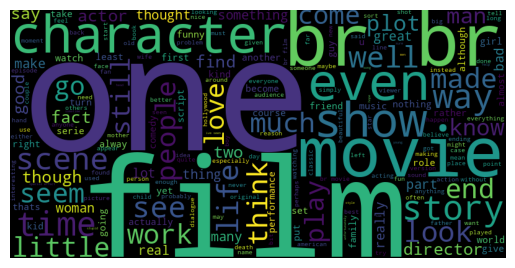

In [111]:
from wordcloud import WordCloud

text = " ".join(df['clean_review'])
wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

## Word Cloud
Visualisasi ini menunjukkan kata-kata yang paling sering muncul dalam dataset.

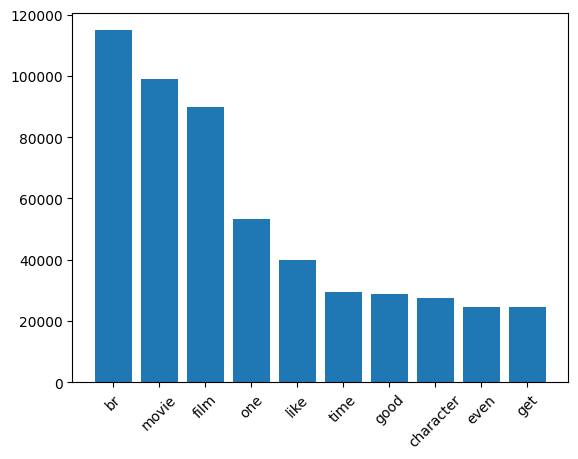

In [112]:
import numpy as np

sum_words = X_bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in bow.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:10]

words = [w[0] for w in words_freq]
freqs = [w[1] for w in words_freq]

plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.show()

## Frekuensi Kata
Menampilkan 10 kata yang paling sering muncul berdasarkan Bag of Words.

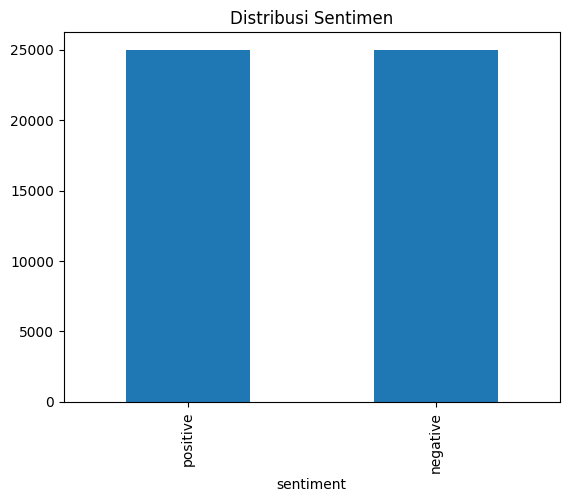

In [113]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen")
plt.show()

## Distribusi Sentimen
Menampilkan jumlah data sentimen positif dan negatif dalam dataset.

## Kesimpulan
TF-IDF memberikan performa yang lebih baik dibandingkan Bag of Words.
Model Naive Bayes mampu mencapai akurasi di atas 84%.
Preprocessing memiliki peran penting dalam meningkatkan kualitas model.